In [19]:
"""
ANALOG CIRCUIT PARAMETER PREDICTION - XGBoost Training Pipeline
================================================================

Training 3 Forward Models:
  - Model 1: (a, b, c, d) → gain
  - Model 2: (a, b, c, d) → pm
  - Model 3: (a, b, c, d) → ugf

No scaling needed for XGBoost (tree-based model)
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from xgboost import XGBRegressor
import joblib
import json
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

In [20]:
# ============================================================================
# CONFIGURATION
# ============================================================================

CONFIG = {
    # Data split
    'test_size': 0.2,
    'random_state': 42,
    
    # XGBoost hyperparameters
    'xgboost': {
        'n_estimators': 200,
        'max_depth': 8,
        'learning_rate': 0.05,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'min_child_weight': 3,
        'gamma': 0,
        'reg_alpha': 0,
        'reg_lambda': 1,
        'random_state': 42,
        'n_jobs': -1,
        'verbosity': 0
    },
    
    # File paths (UPDATE THESE!)
    'files': {
        'gain': 'data/processed/UpdatedOpam/gain_ml.csv',
        'pm': 'data/processed/UpdatedOpam/pm_ml.csv',
        'ugf': 'data/processed/UpdatedOpam/ugf_ml.csv'
    },
    
    # Output directory
    'output_dir': 'trained_models/'
}


print("="*80)
print("XGBOOST MODEL TRAINING PIPELINE")
print("Analog Circuit Parameter Prediction")
print("="*80)
print(f"\nConfiguration:")
print(f"  Test size: {CONFIG['test_size']*100}%")
print(f"  Random state: {CONFIG['random_state']}")
print(f"  XGBoost n_estimators: {CONFIG['xgboost']['n_estimators']}")
print(f"  XGBoost max_depth: {CONFIG['xgboost']['max_depth']}")
print(f"  XGBoost learning_rate: {CONFIG['xgboost']['learning_rate']}")


XGBOOST MODEL TRAINING PIPELINE
Analog Circuit Parameter Prediction

Configuration:
  Test size: 20.0%
  Random state: 42
  XGBoost n_estimators: 200
  XGBoost max_depth: 8
  XGBoost learning_rate: 0.05


In [21]:
df = pd.read_csv(r"D:\UST Project\UST_Analog_automation\data\processed\UpdatedOpam\gain_ml.csv")

dff = pd.read_csv(r"D:\UST Project\UST_Analog_automation\data\processed\UpdatedOpam\pm_ml.csv")

dfff = pd.read_csv(r"D:\UST Project\UST_Analog_automation\data\processed\UpdatedOpam\ugf_ml.csv")

df['pm'] = dff['pm']
df['ugf'] =dfff['ugf']/1e6

In [18]:
df.to_csv("Opam.csv",index=False)

In [22]:
df.head()

,a,b,c,d,gain,pm,ugf
0,0.000011,0.000132,0.000002,0.000038,18.742711,87.258927,12.859450
1,0.000011,0.000132,0.000002,0.000043,20.022486,88.484256,14.297892
2,0.000011,0.000132,0.000002,0.000047,21.220200,89.624073,15.512937
3,0.000011,0.000132,0.000002,0.000051,22.355053,90.908162,17.467633
4,0.000011,0.000132,0.000002,0.000056,23.443796,92.119695,19.572013


In [23]:
# ============================================================================
# STEP 2: DATA PREPARATION
# ============================================================================

def prepare_data(df, test_size, random_state):
    """
    Prepare data for training (NO SCALING for XGBoost)
    
    Args:
        df: Merged DataFrame
        test_size: Fraction for test set
        random_state: Random seed
    
    Returns:
        Dictionary with train/test splits
    """
    print("\n" + "="*80)
    print("STEP 2: DATA PREPARATION")
    print("="*80)
    
    # Extract features (parameters) and targets (specs)
    print("\nExtracting features and targets...")
    X = df[['a', 'b', 'c', 'd']].values
    y_gain = df['gain'].values
    y_pm = df['pm'].values
    y_ugf = df['ugf'].values
    
    print(f"  Feature matrix X: {X.shape}")
    print(f"  Target gain: {y_gain.shape}")
    print(f"  Target pm: {y_pm.shape}")
    print(f"  Target ugf: {y_ugf.shape}")
    
    # Parameter bounds (for optimization later)
    param_bounds = {
        'a': (df['a'].min(), df['a'].max()),
        'b': (df['b'].min(), df['b'].max()),
        'c': (df['c'].min(), df['c'].max()),
        'd': (df['d'].min(), df['d'].max())
    }
    
    print(f"\nParameter Bounds:")
    print(f"  a: [{param_bounds['a'][0]:.6e}, {param_bounds['a'][1]:.6e}]")
    print(f"  b: [{param_bounds['b'][0]:.6e}, {param_bounds['b'][1]:.6e}]")
    print(f"  c: [{param_bounds['c'][0]:.6e}, {param_bounds['c'][1]:.6e}]")
    print(f"  d: [{param_bounds['d'][0]:.6e}, {param_bounds['d'][1]:.6e}]")
    
    # Train-test split
    print(f"\nSplitting data (test_size={test_size})...")
    
    # Use same indices for consistent splitting
    indices = np.arange(len(X))
    train_idx, test_idx = train_test_split(
        indices,
        test_size=test_size,
        random_state=random_state
    )
    
    X_train = X[train_idx]
    X_test = X[test_idx]
    y_train_gain = y_gain[train_idx]
    y_test_gain = y_gain[test_idx]
    y_train_pm = y_pm[train_idx]
    y_test_pm = y_pm[test_idx]
    y_train_ugf = y_ugf[train_idx]
    y_test_ugf = y_ugf[test_idx]
    
    print(f"  ✓ Train samples: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
    print(f"  ✓ Test samples: {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")
    
    print("\n✓ NO SCALING APPLIED (XGBoost doesn't need it!)")
    
    return {
        'X_train': X_train,
        'X_test': X_test,
        'y_train_gain': y_train_gain,
        'y_test_gain': y_test_gain,
        'y_train_pm': y_train_pm,
        'y_test_pm': y_test_pm,
        'y_train_ugf': y_train_ugf,
        'y_test_ugf': y_test_ugf,
        'param_bounds': param_bounds,
        'feature_names': ['a', 'b', 'c', 'd']
    }

# Prepare data
data = prepare_data(df, CONFIG['test_size'], CONFIG['random_state'])


STEP 2: DATA PREPARATION

Extracting features and targets...
  Feature matrix X: (2210, 4)
  Target gain: (2210,)
  Target pm: (2210,)
  Target ugf: (2210,)

Parameter Bounds:
  a: [4.800000e-06, 1.120000e-05]
  b: [0.000000e+00, 3.889991e-04]
  c: [2.400000e-06, 5.600000e-06]
  d: [3.840000e-05, 8.960000e-05]

Splitting data (test_size=0.2)...
  ✓ Train samples: 1768 (80.0%)
  ✓ Test samples: 442 (20.0%)

✓ NO SCALING APPLIED (XGBoost doesn't need it!)


In [13]:
# ============================================================================
# STEP 3: TRAIN MODELS
# ============================================================================

def train_model(X_train, y_train, X_test, y_test, model_name, xgb_params):
    """
    Train a single XGBoost model
    
    Args:
        X_train, y_train: Training data
        X_test, y_test: Test data
        model_name: Name of the model (for logging)
        xgb_params: XGBoost hyperparameters
    
    Returns:
        Trained model and metrics
    """
    import time
    
    print(f"\n{'='*60}")
    print(f"Training {model_name} Model")
    print(f"{'='*60}")
    
    # Create model
    model = XGBRegressor(**xgb_params)
    
    # Train
    print("Training...")
    start_time = time.time()
    model.fit(X_train, y_train)
    training_time = time.time() - start_time
    
    # Predictions
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    
    # Metrics - Train
    train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
    train_mae = mean_absolute_error(y_train, y_pred_train)
    train_r2 = r2_score(y_train, y_pred_train)
    
    # Metrics - Test
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    test_mae = mean_absolute_error(y_test, y_pred_test)
    test_r2 = r2_score(y_test, y_pred_test)
    
    # Calculate MAPE (Mean Absolute Percentage Error)
    train_mape = np.mean(np.abs((y_train - y_pred_train) / y_train)) * 100
    test_mape = np.mean(np.abs((y_test - y_pred_test) / y_test)) * 100
    
    # Overfitting check
    overfit_score = train_r2 - test_r2
    
    # Print results
    print(f"\n✓ Training completed in {training_time:.2f} seconds")
    print(f"\n{'Metric':<20} {'Train':<15} {'Test':<15}")
    print("-" * 50)
    print(f"{'R² Score':<20} {train_r2:<15.6f} {test_r2:<15.6f}")
    print(f"{'RMSE':<20} {train_rmse:<15.6f} {test_rmse:<15.6f}")
    print(f"{'MAE':<20} {train_mae:<15.6f} {test_mae:<15.6f}")
    print(f"{'MAPE (%)':<20} {train_mape:<15.4f} {test_mape:<15.4f}")
    print("-" * 50)
    print(f"{'Overfit (Train-Test R²)':<40} {overfit_score:<15.6f}")
    
    # Feature importance
    feature_importance = model.feature_importances_
    
    metrics = {
        'model_name': model_name,
        'train_r2': float(train_r2),
        'test_r2': float(test_r2),
        'train_rmse': float(train_rmse),
        'test_rmse': float(test_rmse),
        'train_mae': float(train_mae),
        'test_mae': float(test_mae),
        'train_mape': float(train_mape),
        'test_mape': float(test_mape),
        'overfit_score': float(overfit_score),
        'training_time_seconds': float(training_time),
        'feature_importance': {
            'a': float(feature_importance[0]),
            'b': float(feature_importance[1]),
            'c': float(feature_importance[2]),
            'd': float(feature_importance[3])
        }
    }
    
    return model, metrics, y_pred_test

print("\n" + "="*80)
print("STEP 3: MODEL TRAINING")
print("="*80)

# Train Model 1: GAIN
model_gain, metrics_gain, y_pred_gain = train_model(
    data['X_train'],
    data['y_train_gain'],
    data['X_test'],
    data['y_test_gain'],
    'GAIN',
    CONFIG['xgboost']
)

# Train Model 2: PM
model_pm, metrics_pm, y_pred_pm = train_model(
    data['X_train'],
    data['y_train_pm'],
    data['X_test'],
    data['y_test_pm'],
    'PM',
    CONFIG['xgboost']
)

# Train Model 3: UGF
model_ugf, metrics_ugf, y_pred_ugf = train_model(
    data['X_train'],
    data['y_train_ugf'],
    data['X_test'],
    data['y_test_ugf'],
    'UGF',
    CONFIG['xgboost']
)

# Summary
print("\n" + "="*80)
print("TRAINING SUMMARY")
print("="*80)
print(f"\n{'Model':<10} {'Test R²':<12} {'Test RMSE':<12} {'Test MAE':<12} {'Overfit':<12}")
print("-" * 58)
print(f"{'GAIN':<10} {metrics_gain['test_r2']:<12.6f} {metrics_gain['test_rmse']:<12.6f} "
      f"{metrics_gain['test_mae']:<12.6f} {metrics_gain['overfit_score']:<12.6f}")
print(f"{'PM':<10} {metrics_pm['test_r2']:<12.6f} {metrics_pm['test_rmse']:<12.6f} "
      f"{metrics_pm['test_mae']:<12.6f} {metrics_pm['overfit_score']:<12.6f}")
print(f"{'UGF':<10} {metrics_ugf['test_r2']:<12.6f} {metrics_ugf['test_rmse']:<12.6f} "
      f"{metrics_ugf['test_mae']:<12.6f} {metrics_ugf['overfit_score']:<12.6f}")
print("-" * 58)

avg_r2 = (metrics_gain['test_r2'] + metrics_pm['test_r2'] + metrics_ugf['test_r2']) / 3
print(f"\nAverage Test R²: {avg_r2:.6f}")



STEP 3: MODEL TRAINING

Training GAIN Model
Training...

✓ Training completed in 0.57 seconds

Metric               Train           Test           
--------------------------------------------------
R² Score             0.999504        0.997136       
RMSE                 0.344839        0.822292       
MAE                  0.170119        0.348699       
MAPE (%)             0.7701          1.4865         
--------------------------------------------------
Overfit (Train-Test R²)                  0.002368       

Training PM Model
Training...

✓ Training completed in 0.27 seconds

Metric               Train           Test           
--------------------------------------------------
R² Score             0.994646        0.960240       
RMSE                 0.706319        1.922195       
MAE                  0.310272        0.661269       
MAPE (%)             0.3673          0.8065         
--------------------------------------------------
Overfit (Train-Test R²)                  0.


STEP 4: CREATING VISUALIZATIONS

✓ Visualizations saved as 'model_training_results.png'


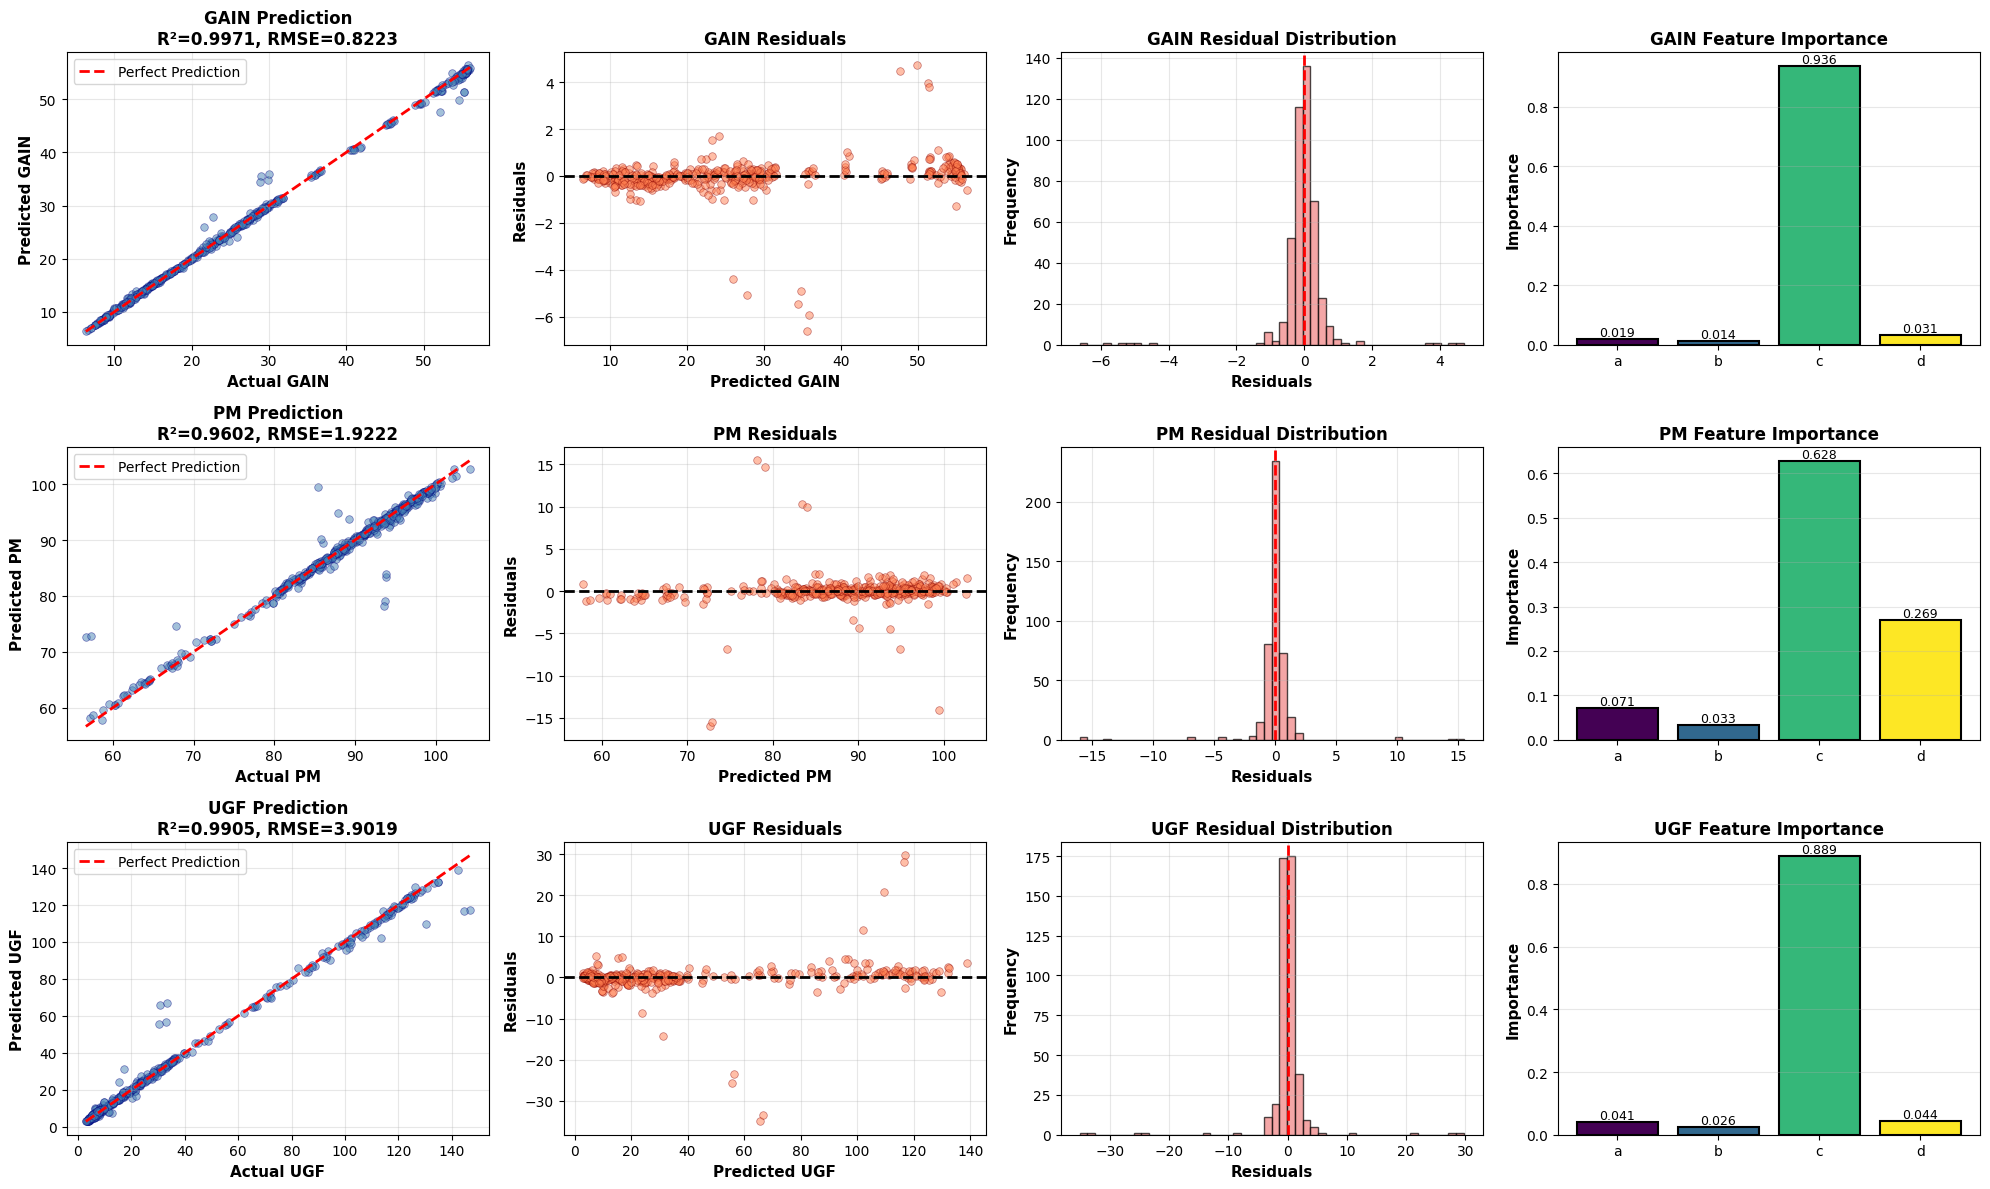

In [14]:
# ============================================================================
# STEP 4: VISUALIZATIONS
# ============================================================================

def create_visualizations(data, metrics_list, predictions_list):
    """
    Create comprehensive visualizations of model performance
    """
    print("\n" + "="*80)
    print("STEP 4: CREATING VISUALIZATIONS")
    print("="*80)
    
    fig = plt.figure(figsize=(20, 12))
    
    specs = [
        ('GAIN', data['y_test_gain'], predictions_list[0], metrics_list[0]),
        ('PM', data['y_test_pm'], predictions_list[1], metrics_list[1]),
        ('UGF', data['y_test_ugf'], predictions_list[2], metrics_list[2])
    ]
    
    for idx, (name, y_test, y_pred, metrics) in enumerate(specs):
        
        # 1. Prediction Scatter Plot
        ax1 = plt.subplot(3, 4, idx*4 + 1)
        ax1.scatter(y_test, y_pred, alpha=0.5, s=30, color='steelblue', 
                   edgecolors='navy', linewidth=0.5)
        ax1.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
                'r--', lw=2, label='Perfect Prediction')
        ax1.set_xlabel(f'Actual {name}', fontsize=11, fontweight='bold')
        ax1.set_ylabel(f'Predicted {name}', fontsize=11, fontweight='bold')
        ax1.set_title(f'{name} Prediction\nR²={metrics["test_r2"]:.4f}, RMSE={metrics["test_rmse"]:.4f}',
                     fontsize=12, fontweight='bold')
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        
        # 2. Residual Plot
        ax2 = plt.subplot(3, 4, idx*4 + 2)
        residuals = y_test - y_pred
        ax2.scatter(y_pred, residuals, alpha=0.5, s=30, color='coral',
                   edgecolors='darkred', linewidth=0.5)
        ax2.axhline(y=0, color='black', linestyle='--', linewidth=2)
        ax2.set_xlabel(f'Predicted {name}', fontsize=11, fontweight='bold')
        ax2.set_ylabel('Residuals', fontsize=11, fontweight='bold')
        ax2.set_title(f'{name} Residuals', fontsize=12, fontweight='bold')
        ax2.grid(True, alpha=0.3)
        
        # 3. Residual Distribution
        ax3 = plt.subplot(3, 4, idx*4 + 3)
        ax3.hist(residuals, bins=50, edgecolor='black', alpha=0.7, color='lightcoral')
        ax3.axvline(x=0, color='red', linestyle='--', linewidth=2)
        ax3.set_xlabel('Residuals', fontsize=11, fontweight='bold')
        ax3.set_ylabel('Frequency', fontsize=11, fontweight='bold')
        ax3.set_title(f'{name} Residual Distribution', fontsize=12, fontweight='bold')
        ax3.grid(True, alpha=0.3)
        
        # 4. Feature Importance
        ax4 = plt.subplot(3, 4, idx*4 + 4)
        features = ['a', 'b', 'c', 'd']
        importance = [metrics['feature_importance'][f] for f in features]
        colors_imp = plt.cm.viridis(np.linspace(0, 1, len(features)))
        bars = ax4.bar(features, importance, color=colors_imp, edgecolor='black', linewidth=1.5)
        ax4.set_ylabel('Importance', fontsize=11, fontweight='bold')
        ax4.set_title(f'{name} Feature Importance', fontsize=12, fontweight='bold')
        ax4.grid(True, alpha=0.3, axis='y')
        
        # Add value labels on bars
        for bar in bars:
            height = bar.get_height()
            ax4.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.3f}', ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.savefig('model_training_results.png', dpi=300, bbox_inches='tight')
    print("\n✓ Visualizations saved as 'model_training_results.png'")
    plt.show()
    
    return fig

# Create visualizations
fig = create_visualizations(
    data,
    [metrics_gain, metrics_pm, metrics_ugf],
    [y_pred_gain, y_pred_pm, y_pred_ugf]
)

In [15]:
# ============================================================================
# STEP 5: SAVE MODELS AND METADATA
# ============================================================================

def save_models_and_metadata(models, metrics_list, data, config):
    """
    Save trained models and all metadata
    """
    print("\n" + "="*80)
    print("STEP 5: SAVING MODELS AND METADATA")
    print("="*80)
    
    import os
    
    # Create output directory
    os.makedirs(config['output_dir'], exist_ok=True)
    print(f"\nOutput directory: {config['output_dir']}")
    
    # Save models
    print("\nSaving models...")
    model_files = {
        'gain': 'model_gain_xgboost.pkl',
        'pm': 'model_pm_xgboost.pkl',
        'ugf': 'model_ugf_xgboost.pkl'
    }
    
    for (name, model), (_, filename) in zip(models.items(), model_files.items()):
        filepath = os.path.join(config['output_dir'], filename)
        joblib.dump(model, filepath)
        print(f"  ✓ {filename}")
    
    # Save parameter bounds
    bounds_file = os.path.join(config['output_dir'], 'param_bounds.pkl')
    joblib.dump(data['param_bounds'], bounds_file)
    print(f"  ✓ param_bounds.pkl")
    
    # Save metrics as JSON
    print("\nSaving metrics...")
    all_metrics = {
        'gain': metrics_list[0],
        'pm': metrics_list[1],
        'ugf': metrics_list[2],
        'summary': {
            'average_test_r2': (metrics_list[0]['test_r2'] + 
                               metrics_list[1]['test_r2'] + 
                               metrics_list[2]['test_r2']) / 3,
            'training_date': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
            'total_samples': len(data['X_train']) + len(data['X_test']),
            'train_samples': len(data['X_train']),
            'test_samples': len(data['X_test'])
        }
    }
    
    metrics_file = os.path.join(config['output_dir'], 'model_metrics.json')
    with open(metrics_file, 'w') as f:
        json.dump(all_metrics, f, indent=2)
    print(f"  ✓ model_metrics.json")
    
    # Save configuration
    config_file = os.path.join(config['output_dir'], 'training_config.json')
    with open(config_file, 'w') as f:
        json.dump(config, f, indent=2)
    print(f"  ✓ training_config.json")
    
    print("\n✓ All models and metadata saved successfully!")
    
    return model_files, metrics_file, config_file

# Save everything
models_dict = {
    'gain': model_gain,
    'pm': model_pm,
    'ugf': model_ugf
}

saved_files = save_models_and_metadata(
    models_dict,
    [metrics_gain, metrics_pm, metrics_ugf],
    data,
    CONFIG
)


STEP 5: SAVING MODELS AND METADATA

Output directory: trained_models/

Saving models...
  ✓ model_gain_xgboost.pkl
  ✓ model_pm_xgboost.pkl
  ✓ model_ugf_xgboost.pkl
  ✓ param_bounds.pkl

Saving metrics...
  ✓ model_metrics.json
  ✓ training_config.json

✓ All models and metadata saved successfully!


In [16]:
# ============================================================================
# FINAL SUMMARY
# ============================================================================

print("\n" + "="*80)
print("✅ TRAINING COMPLETE!")
print("="*80)

print(f"\n📊 Performance Summary:")
print(f"  GAIN Model: R²={metrics_gain['test_r2']:.4f}, RMSE={metrics_gain['test_rmse']:.4f}")
print(f"  PM Model:   R²={metrics_pm['test_r2']:.4f}, RMSE={metrics_pm['test_rmse']:.4f}")
print(f"  UGF Model:  R²={metrics_ugf['test_r2']:.4f}, RMSE={metrics_ugf['test_rmse']:.4f}")

print(f"\n💾 Saved Files:")
print(f"  Models: {CONFIG['output_dir']}")
print(f"    - model_gain_xgboost.pkl")
print(f"    - model_pm_xgboost.pkl")
print(f"    - model_ugf_xgboost.pkl")
print(f"    - param_bounds.pkl")
print(f"    - model_metrics.json")
print(f"    - training_config.json")

print(f"\n📈 Visualizations:")
print(f"    - model_training_results.png")

print(f"\n🎯 Next Steps:")
print(f"  1. Review visualizations")
print(f"  2. Check model_metrics.json for detailed performance")
print(f"  3. Proceed with optimization implementation")

print("\n" + "="*80)

# ============================================================================
# USAGE EXAMPLE
# ============================================================================

print("\n" + "="*80)
print("USAGE EXAMPLE - How to Load and Use Models")
print("="*80)

usage_example = """
# ============================================================================
# Load trained models
# ============================================================================

import joblib
import numpy as np

# Load models
model_gain = joblib.load('trained_models/model_gain_xgboost.pkl')
model_pm = joblib.load('trained_models/model_pm_xgboost.pkl')
model_ugf = joblib.load('trained_models/model_ugf_xgboost.pkl')

# Load parameter bounds (for optimization later)
param_bounds = joblib.load('trained_models/param_bounds.pkl')

# ============================================================================
# Make predictions (forward pass)
# ============================================================================

# Example: predict specs for given parameters
params = np.array([[0.00005, 0.00003, 0.00002, 0.00001]])  # Shape: (1, 4)

predicted_gain = model_gain.predict(params)[0]
predicted_pm = model_pm.predict(params)[0]
predicted_ugf = model_ugf.predict(params)[0]

print(f"For parameters: a={params[0,0]}, b={params[0,1]}, c={params[0,2]}, d={params[0,3]}")
print(f"Predicted GAIN: {predicted_gain:.4f}")
print(f"Predicted PM:   {predicted_pm:.4f}")
print(f"Predicted UGF:  {predicted_ugf:.4f}")

# ============================================================================
# Batch predictions
# ============================================================================

# Multiple parameter sets
params_batch = np.array([
    [0.00005, 0.00003, 0.00002, 0.00001],
    [0.00006, 0.00004, 0.00003, 0.00002],
    [0.00007, 0.00005, 0.00004, 0.00003]
])

gains = model_gain.predict(params_batch)
pms = model_pm.predict(params_batch)
ugfs = model_ugf.predict(params_batch)

for i in range(len(params_batch)):
    print(f"Set {i+1}: GAIN={gains[i]:.4f}, PM={pms[i]:.4f}, UGF={ugfs[i]:.4f}")
"""

print(usage_example)
print("="*80)


✅ TRAINING COMPLETE!

📊 Performance Summary:
  GAIN Model: R²=0.9971, RMSE=0.8223
  PM Model:   R²=0.9602, RMSE=1.9222
  UGF Model:  R²=0.9905, RMSE=3.9019

💾 Saved Files:
  Models: trained_models/
    - model_gain_xgboost.pkl
    - model_pm_xgboost.pkl
    - model_ugf_xgboost.pkl
    - param_bounds.pkl
    - model_metrics.json
    - training_config.json

📈 Visualizations:
    - model_training_results.png

🎯 Next Steps:
  1. Review visualizations
  2. Check model_metrics.json for detailed performance
  3. Proceed with optimization implementation


USAGE EXAMPLE - How to Load and Use Models

# ============================================================================
# Load trained models
# ============================================================================

import joblib
import numpy as np

# Load models
model_gain = joblib.load('trained_models/model_gain_xgboost.pkl')
model_pm = joblib.load('trained_models/model_pm_xgboost.pkl')
model_ugf = joblib.load('trained_models/mode

In [28]:
print(data['X_test'][0])

[1.013333e-05 3.889991e-04 5.066667e-06 8.110000e-05]


In [27]:
print(data['y_test_gain'][0])
print(data['y_test_pm'][0])
print(data['y_test_ugf'][0])

55.10516431
66.97095421
120.42698870000001


In [ ]:
a = 1.103786e-05
b = 2.894018e-04
c = 5.071227e-06
d = 7.787758e-05